In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", 
    "marital-status", "occupation", "relationship", "race", "sex", 
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]
df = pd.read_csv('../dataset/adult/adult.data', header=None, names=columns, na_values='?')
df.sample(100)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
29588,28,Private,116613,Some-college,10,Never-married,Tech-support,Own-child,White,Female,0,0,24,United-States,<=50K
27466,68,?,152157,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,0,20,United-States,<=50K
23144,21,Private,296158,10th,6,Married-civ-spouse,Other-service,Husband,White,Male,0,0,25,United-States,<=50K
13937,36,Federal-gov,44364,HS-grad,9,Never-married,Adm-clerical,Own-child,Black,Female,0,0,36,United-States,<=50K
26081,40,?,165309,7th-8th,4,Separated,?,Not-in-family,White,Female,0,0,8,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12805,28,Self-emp-not-inc,182826,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,35,United-States,<=50K
9038,25,Private,75759,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,44,United-States,>50K
7435,27,Private,107218,HS-grad,9,Never-married,Other-service,Own-child,Asian-Pac-Islander,Male,0,0,40,United-States,<=50K
8461,38,Private,108140,Bachelors,13,Never-married,Other-service,Not-in-family,White,Male,0,0,20,United-States,<=50K


In [3]:
df = df.apply(lambda col: col.astype(str).str.strip())
df.replace('?', np.nan, inplace=True)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  object
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  object
 3   education       32561 non-null  object
 4   education-num   32561 non-null  object
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  object
 11  capital-loss    32561 non-null  object
 12  hours-per-week  32561 non-null  object
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: object(15)
memory usage: 3.7+ MB


In [5]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

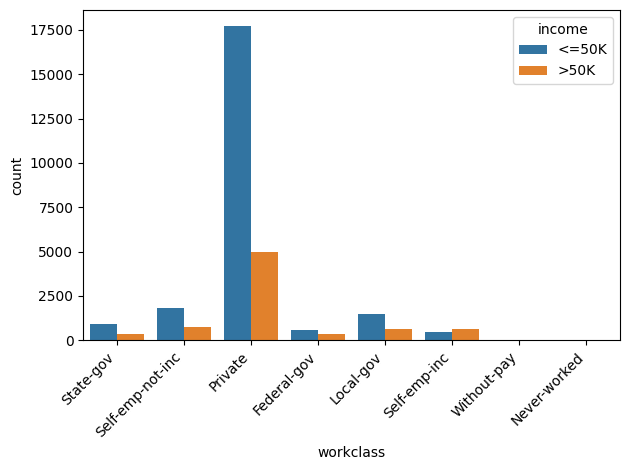

In [6]:
sns.countplot(data=df, x='workclass', hue='income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [8]:
df['workclass'] = df.groupby('occupation')['workclass'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

df['workclass'] = df['workclass'].fillna(df.groupby('education')['workclass'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else "Private")
)

In [9]:
df['occupation'] = df.groupby('education')['occupation'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

In [10]:
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])

In [11]:
col_transform = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'fnlwgt']
for col in col_transform:
    df[col] = pd.to_numeric(df[col], errors='coerce')

<Axes: xlabel='income', ylabel='count'>

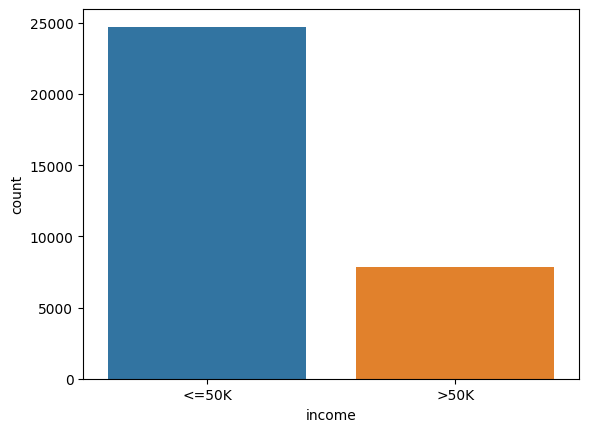

In [12]:
sns.countplot(data=df, x='income', hue='income')

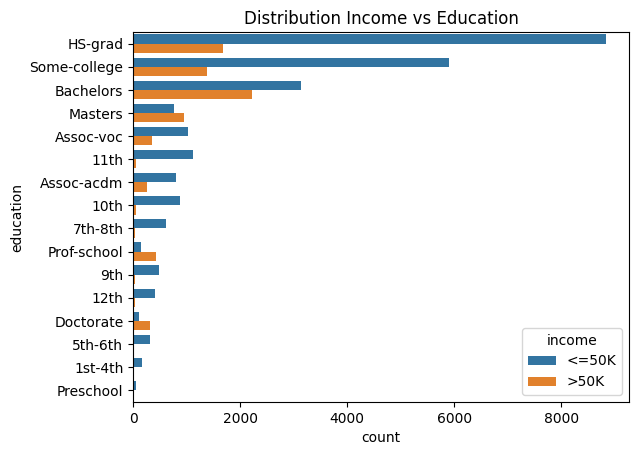

In [13]:
sns.countplot(y='education', hue='income', data=df, order=df['education'].value_counts().index)
plt.title('Distribution Income vs Education')
plt.show()

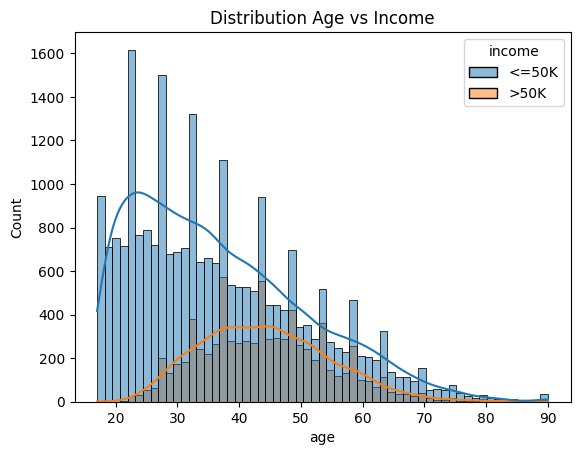

In [14]:
sns.histplot(data=df, x='age', hue='income', kde=True)
plt.title('Distribution Age vs Income')
plt.show()

<Axes: xlabel='capital-gain'>

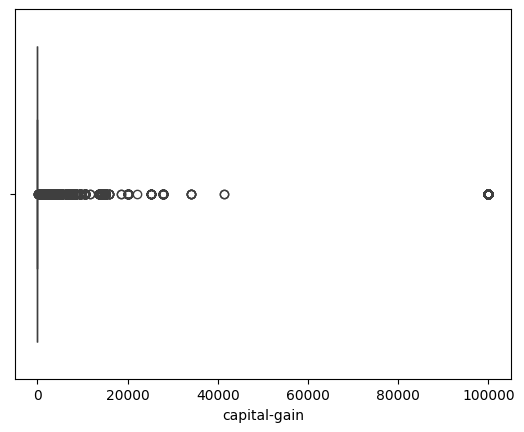

In [15]:
sns.boxplot(x=df['capital-gain'])

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])
print("Mapping kelas:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping kelas: {'<=50K': np.int64(0), '>50K': np.int64(1)}


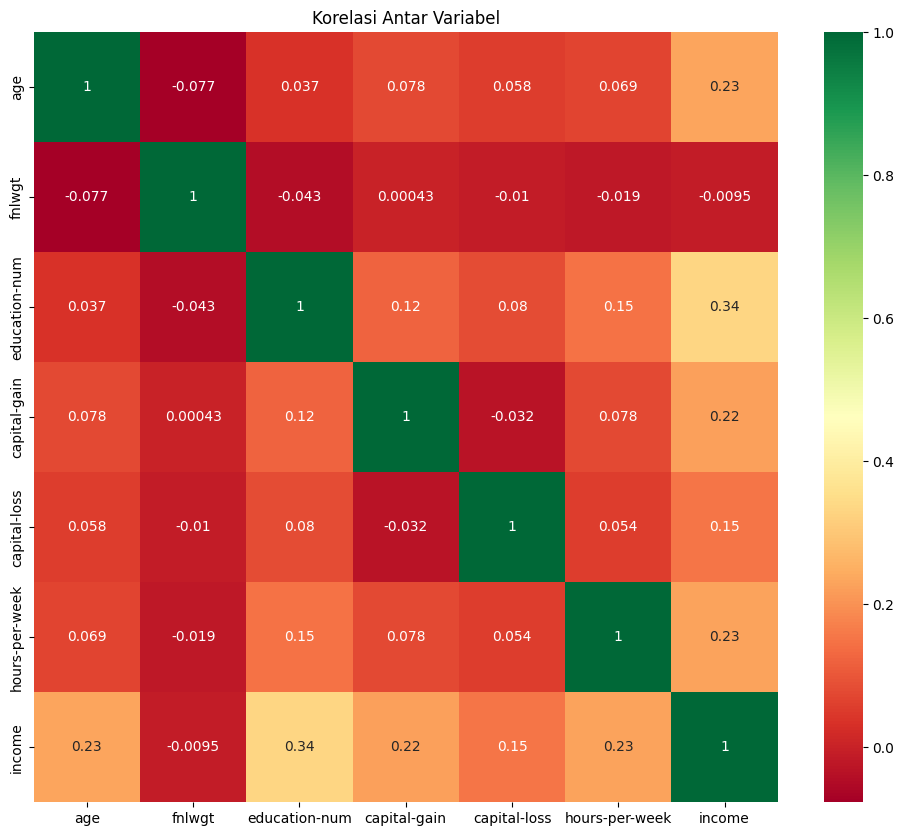

In [27]:
korelasi = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(korelasi, annot=True, cmap='RdYlGn')
plt.title('Korelasi Antar Variabel')
plt.show()

In [28]:
print(df.corr(numeric_only=True)['income'].sort_values(ascending=False))

income            1.000000
education-num     0.335154
age               0.234037
hours-per-week    0.229689
capital-gain      0.223329
capital-loss      0.150526
fnlwgt           -0.009463
Name: income, dtype: float64


In [31]:
df = df.drop(columns=['fnlwgt', 'education'])

In [32]:
df_train = pd.get_dummies(df, drop_first=True)

In [34]:
from sklearn.model_selection import train_test_split
X = df_train.drop(columns='income', axis=1)
y = df_train['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [38]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [39]:
y_pred = svm_model.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.8507600184246891

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91      4942
           1       0.75      0.57      0.65      1571

    accuracy                           0.85      6513
   macro avg       0.81      0.76      0.78      6513
weighted avg       0.84      0.85      0.84      6513

